In [ ]:
# --- Import Tool Wrappers ---
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools.tavily_search import TavilySearchResults

# DuckDuckGo Search Tool
search_tool = DuckDuckGoSearchRun()
print(search_tool.name)

# Tavily Search Tool (API key added directly here)
tavily_tool = TavilySearchResults(tavily_api_key="https://app.tavily.com/home?ph_referrer=www.bing.com")

# Try invoking
search_tool.invoke("Latest IPL news 2026")

duckduckgo_search


'3 hours ago ... The official IPL website with live scores, match updates, team rankings, all the latest news, and videos . Follow your favorite teams and players! 14 Nov 2025 ... The IPL 2026 auction is scheduled to take place on December 16, 2025, at the Etihad Arena in Abu Dhabi, UAE. The Board of Control for Cricket in India ... 6 May 2026 ... The IPL 2026 season kicked off on March 28, with reigning Indian Premier League champions Royal Challengers Bengaluru hosting Sunrisers Hyderabad in the ... 24 Mar 2026 ... IPL 2026 Build-up Live Updates: Kolkata Knight Riders are poised to bring in Vidarbha left-arm pacer Saurabh Dubey as a replacement for injured India seamer ... 11 Mar 2026 ... IndianPremierLeague (@IPL). 220 replies. News Presenting the schedule for the first 20 matches of #TATAIPL 2026, to be played from March 28 to April 12, ...'

In [21]:
tavily_tool.invoke("IPL 2026 final date")

[{'title': '2026 Indian Premier League',
  'url': 'https://en.wikipedia.org/wiki/2026_Indian_Premier_League',
  'content': '29 May,( and the final at Narendra Modi Stadium on 31 May, with the venue hosting its fourth final after 2022, 2023 and 2025.( [...] In March 2026, it was announced that the fixtures for that season would be announced in two parts due to the state assembly elections in Assam, Tamil Nadu, and West Bengal;( for which the dates were not announced till 15 March.( The first part of the schedule comprising the first twenty matches was announced on 11 March, with the inaugural match being hosted at M. Chinnaswamy Stadium between the defending champions Royal Challengers Bengaluru and Sunrisers Hyderabad on 28 March.( The complete fixtures for the league stage were announced on 26 March.( On 6 May the playoff fixtures were confirmed( with the qualifier 1 at HPCA Cricket Stadium on 26 May, the eliminator and qualifier 2 at Maharaja Yadavindra Singh Stadium on 27 and 29 May

In [ ]:
# --- Environment Setup ---
import os
os.environ["GROQ_API_KEY"] = "Enter you GROQ API here"
os.environ["LANGCHAIN_API_KEY"] = "your_langchain_api_key_here"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agent-Demo"

# --- Custom Math Functions ---
def square(x: int) -> int:
    """Return square of x."""
    return x * x

def subtract(a: int, b: int) -> int:
    """Subtract b from a."""
    return a - b

def average(numbers: list[int]) -> float:
    """Return average of a list."""
    return sum(numbers) / len(numbers)

def add(numbers: list[int]) -> float:
    """Return average of a list."""
    return sum(numbers)

In [22]:
# Collect tools
tools = [search_tool, tavily_tool, square, subtract, average , add]

# --- Initialize LLM ---
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")

llm_with_tools = llm.bind_tools(tools)

# --- Try invoking ---
from langchain_core.messages import HumanMessage
response = llm_with_tools.invoke([HumanMessage(content="short summary of todays ipl match and square 12")])
print(response)

content='' additional_kwargs={'tool_calls': [{'id': '0hbdftq7j', 'function': {'arguments': '{"query":"today\'s ipl match"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '7drx3xp7x', 'function': {'arguments': '{"x":12}', 'name': 'square'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 601, 'total_tokens': 636, 'completion_time': 0.060749982, 'completion_tokens_details': None, 'prompt_time': 0.080496425, 'prompt_tokens_details': None, 'queue_time': 0.157404131, 'total_time': 0.141246407}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e64e1-9da7-7e90-980e-b42accd4e82f-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': "today's ipl match"}, 'id': '0hbdftq7j', 'type': 'tool_call'}, {'name': 'square', 'args': {'x': 12}, 'id': '7drx3xp7x', 'type': 't

In [5]:
# --- LangGraph Setup ---
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

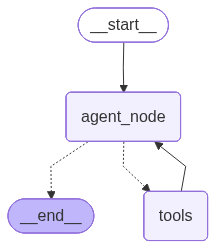

In [23]:
# Node definition
def agent_node(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("agent_node", agent_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent_node")
builder.add_conditional_edges("agent_node", tools_condition)
builder.add_edge("tools", "agent_node")

graph = builder.compile()

# --- Visualize ---
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
messages = graph.invoke({"messages": HumanMessage(content="tell me about ms.dhoni")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

tell me about ms.dhoni
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (yy0e2yd85)
 Call ID: yy0e2yd85
  Args:
    query: ms dhoni
  tavily_search_results_json (j4d3182re)
 Call ID: j4d3182re
  Args:
    query: ms dhoni
================================= Tool Message =================================
Name: duckduckgo_search

MS Dhoni birthday: What are some of the nicknames of Mahendra Singh Dhoni?" . ... How Captain Cool MS Dhoni learnt to give up football and take to ... Mahendra Singh Dhoni, born on 7 July 1981 in Ranchi, Jharkhand, India, is a former international cricketer renowned for his roles as a right-handed batsman, wicketkeeper, and captain of the... MS Dhoni led India to three ICC titles but he is nearly as famous for his exploits in the yellow of Chennai Super Kings in the IPL. MS Dhoni is also hailed for winning the first editi

In [26]:
messages = graph.invoke({"messages": HumanMessage(content="what the best score")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what the best score
================================== Ai Message ==================================

I'm not sure what you're asking for. Can you provide more context or clarify your question?


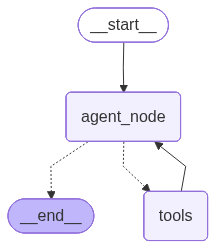

In [27]:
# --- Add MemorySaver ---
from langgraph.checkpoint.memory import MemorySaver

# Create a memory checkpointer
memory = MemorySaver()

# Compile the graph with memory enabled
graph_memory = builder.compile(checkpointer=memory)

# --- Visualize Graph with Memory ---
display(Image(graph_memory.get_graph().draw_mermaid_png()))

# --- Run Example with Memory ---
# Thread ID keeps track of one conversation
config = {"configurable": {"thread_id": "1"}}

In [28]:
# First input
messages = [HumanMessage(content="tell me about MS dhoni in 1 line")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about MS dhoni in 1 line
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (z9egjjzgm)
 Call ID: z9egjjzgm
  Args:
    query: MS Dhoni
================================= Tool Message =================================
Name: duckduckgo_search

Mahendra Singh Dhoni, born on 7 July 1981 in Ranchi, Jharkhand, India, is a former international cricketer renowned for his roles as a right-handed batsman, wicketkeeper, and captain of the... “The point is, MS Dhoni loves CSK a lot. But what I saw yesterday (Monday) during the lap, love was not visible to me. Dhoni Six 2011. Virendra Sehwag Cricket. Twitter Unites In Wishing MSD A Very Happy 39th Birthday | Birthday quotes funny, 39 birthday quotes funny, Best funny jokes. Known for his lightning-fast stumpings and calm finishing, he holds the record for the most dismissals (91) by a wicketkeeper i

In [29]:
# First input
messages = [HumanMessage(content="what is his best score")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about MS dhoni in 1 line
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (z9egjjzgm)
 Call ID: z9egjjzgm
  Args:
    query: MS Dhoni
================================= Tool Message =================================
Name: duckduckgo_search

Mahendra Singh Dhoni, born on 7 July 1981 in Ranchi, Jharkhand, India, is a former international cricketer renowned for his roles as a right-handed batsman, wicketkeeper, and captain of the... “The point is, MS Dhoni loves CSK a lot. But what I saw yesterday (Monday) during the lap, love was not visible to me. Dhoni Six 2011. Virendra Sehwag Cricket. Twitter Unites In Wishing MSD A Very Happy 39th Birthday | Birthday quotes funny, 39 birthday quotes funny, Best funny jokes. Known for his lightning-fast stumpings and calm finishing, he holds the record for the most dismissals (91) by a wicketkeeper i

In [37]:
config = {"configurable": {"thread_id": "3"}}

In [36]:
messages = [HumanMessage(content="what is his high score? give answer in one line")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is his high score? give answer in one line
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (3cxcd3kzz)
 Call ID: 3cxcd3kzz
  Args:
    query: his high score
================================= Tool Message =================================
Name: duckduckgo_search

Howard Leslie Shore (born October 18, 1946) is a Canadian composer, conductor, and orchestrator noted for his film scores. Unofficially, William James Sidis had the highest IQ in the world, with a score in the 250–300 range. Mitch has been a fan of Nintendo ever since he got his start on the GBA in 2005.Twin galaxies should have his tape or they shouldn't have given him high score. Content Description: a black background with the words high score written in white letters. File Size: 766KB. Duration: 0.500 sec. The goal is getting the highest score possible.
=====================

In [18]:
messages = [HumanMessage(content="MS dhoni? give answer in one line")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is his high score? give answer in one line
================================ Human Message =================================

what is his high score? give answer in one line
================================== Ai Message ==================================

I need more information about 'his'. Could you please specify whose high score you are referring to?
================================ Human Message =================================

MS dhoni? give answer in one line
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (bgff06y95)
 Call ID: bgff06y95
  Args:
    query: MS Dhoni high score
================================= Tool Message =================================
Name: duckduckgo_search

MS Dhoni boasts 24 half-centuries in IPL and his highest score is an unbeaten 84 against Royal Challengers Bengaluru. Find out the complete career hist

In [19]:
messages = [HumanMessage(content="MS Dhoni? give answer in one line")]

# Run with streaming
for step in graph_memory.stream({"messages": messages}, config=config):
    print(step) 

{'agent_node': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't8yseaket', 'function': {'arguments': '{"query":"MS Dhoni highest score in ODI"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 952, 'total_tokens': 976, 'completion_time': 0.027729794, 'completion_tokens_details': None, 'prompt_time': 0.32037024, 'prompt_tokens_details': None, 'queue_time': 0.144301126, 'total_time': 0.348100034}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e64a0-fc72-75e2-ad49-ed3caba3d5db-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'MS Dhoni highest score in ODI'}, 'id': 't8yseaket', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 952, 'output_tokens': 24, 'total_tokens': 976})]}}
{'tools': {